In [1]:
#importing all libraries and loading the dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv('ford_car_dataset.csv')


In [ ]:

print("Top 5 rows:")
print(df.head(5))
print("Bottom 5 rows:")
print(df.tail(5))
print("Shape of dataset :",df.shape)
print("Data types of the column:")
print(df.dtypes)

#Structure of the dataset 
# Columns: 9   Rows:17966
#Datatypes: 
# str,int64,float64,object

Top 5 rows:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
Bottom 5 rows:
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    16700   Petrol  150  47.1   
17962   B-MAX  2014   7499       Manual    40700   Petrol   30  57.7   
17963   Focus  2015   9999       Manual     7010   Diesel   20  67.3   
17964      KA  2018   8299       Manual     5007   Petrol  145  57.7   
17965   Focus  2015   8299       Manual     5007   Petrol   22  57.7   

       engineSize  
17961         1.4  
17962         1.0  
17963       

In [ ]:
print(df.isnull().sum())
df = df.drop_duplicates()
print(df.shape)

#From the output, there are no null values in the dataset but if they occur they we can remove it or replace it 
#with mean value of that column

#I removed the duplicates using drop_duplicates method
#as the number of rows changed from 17966 to 17812 there were  154 duplicate values



model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
(17812, 9)
               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min  

In [9]:
print(df.describe())

key_cols = ['price', 'mileage', 'year']
for col in key_cols:
    print(col, df[col].min(), df[col].max(), df[col].mean() , df[col].median())


               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
price 495 54995 12269.556310352571 11288.0
mileage 1 177644 23381.146362003143 18

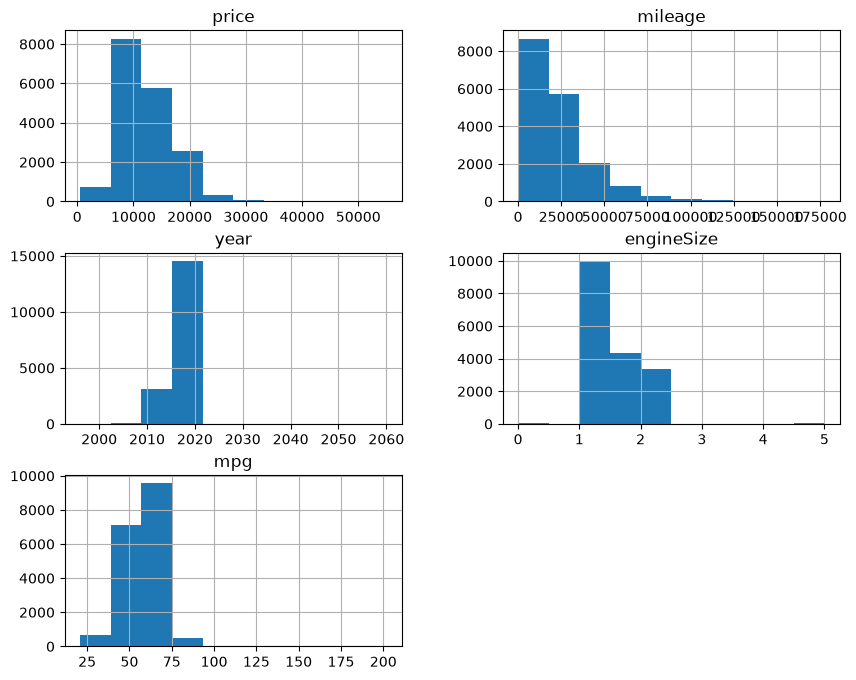

In [10]:
numeric_cols = ['price', 'mileage', 'year', 'engineSize', 'mpg']
df[numeric_cols].hist(figsize=(10,8))
plt.show()

In [35]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

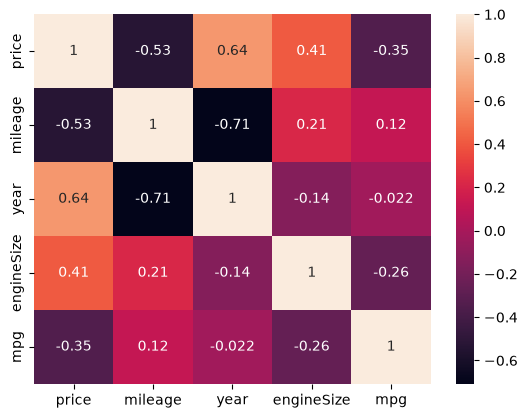

In [15]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True)
plt.show()

In [36]:
X = df.drop('price', axis=1)
y = df['price']
print(y)
#Chosed price as Ouput feature as we need to pridict the price and 
#other are input feature needed to pridict the price

0        12000.0
1        14000.0
2        13000.0
3        17500.0
4        16500.0
          ...   
14556        NaN
15121        NaN
15127        NaN
15685        NaN
17608        NaN
Name: price, Length: 17966, dtype: float64


In [37]:
print(df[categorical_cols].head())
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)
print(df.head())

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
     year    price  mileage    tax   mpg  engineSize  model_ B-MAX  \
0  2017.0  12000.0  15944.0  150.0  57.7         1.0           0.0   
1  2018.0  14000.0   9083.0  150.0  57.7         1.0           0.0   
2  2017.0  13000.0  12456.0  150.0  57.7         1.0           0.0   
3  2019.0  17500.0  10460.0  145.0  40.3         1.5           0.0   
4  2019.0  16500.0   1482.0  145.0  48.7         1.0           0.0   

   model_ C-MAX  model_ EcoSport  model_ Edge  ...  model_ Transit Tourneo  \
0           0.0              0.0          0.0  ...                     0.0   
1           0.0              0.0          0.0  ...                     0.0   
2           0.0              0.0          0.0  ...                     0.0   
3           0.0              0.0          0.0  ...                     0.0   
4           0.0              0.0          0.0  ...                     0.0   

   model_Focus  transmission_Automatic  transmission_Manual

In [41]:
num_features = df.select_dtypes(include=['int64','float64']).columns.tolist()
num_features = [col for col in num_features if col!= 'price']

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])
print("Five rows of scaled data:")
print(df[num_features].head(5))


Five rows of scaled data:
       year   mileage       tax       mpg  engineSize  model_ B-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561     -0.141575   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561     -0.141575   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561     -0.141575   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325     -0.141575   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561     -0.141575   

   model_ C-MAX  model_ EcoSport  model_ Edge  model_ Escort  ...  \
0     -0.177155        -0.259896    -0.107903      -0.007493  ...   
1     -0.177155        -0.259896    -0.107903      -0.007493  ...   
2     -0.177155        -0.259896    -0.107903      -0.007493  ...   
3     -0.177155        -0.259896    -0.107903      -0.007493  ...   
4     -0.177155        -0.259896    -0.107903      -0.007493  ...   

   model_ Transit Tourneo  model_Focus  transmission_Automatic  \
0               -0.007493    -0.007493                3.486416   


In [44]:
def preprocess(path):
    data = pd.read_csv(path)
    data = data.drop_duplicates()
    data = data.fillna(data.mean(numeric_only=True))

    numeric_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
    categorical_cols = data.select_dtypes(include='object').columns.tolist()

    data[numeric_cols].hist(figsize=(10,8))
    plt.show()

    for col in categorical_cols:
        plt.figure(figsize=(8,4))
        sns.countplot(x=data[col], order=data[col].value_counts().index)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    corr = data[numeric_cols].corr()
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True)
    plt.show()

    X = data.drop('price', axis=1)
    y = data['price']

    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
    scaler = StandardScaler()
    X[num_features] = scaler.fit_transform(X[num_features])

    return X, y
print(X)
print(y)


         year  mileage    tax   mpg  engineSize  model_ B-MAX  model_ C-MAX  \
0      2017.0  15944.0  150.0  57.7         1.0           0.0           0.0   
1      2018.0   9083.0  150.0  57.7         1.0           0.0           0.0   
2      2017.0  12456.0  150.0  57.7         1.0           0.0           0.0   
3      2019.0  10460.0  145.0  40.3         1.5           0.0           0.0   
4      2019.0   1482.0  145.0  48.7         1.0           0.0           0.0   
...       ...      ...    ...   ...         ...           ...           ...   
14556     NaN      NaN    NaN   NaN         NaN           0.0           0.0   
15121     NaN      NaN    NaN   NaN         NaN           0.0           0.0   
15127     NaN      NaN    NaN   NaN         NaN           0.0           0.0   
15685     NaN      NaN    NaN   NaN         NaN           0.0           0.0   
17608     NaN      NaN    NaN   NaN         NaN           0.0           0.0   

       model_ EcoSport  model_ Edge  model_ Escort 